# Training Dataset Bahasa Isyarat menggunakan CNN + LSTM (PyTorch)

Versi PyTorch dari `CNN_LSTM_independent_dataset.ipynb`. Notebook ini mempertahankan preprocessing, augmentasi, pembagian dataset, evaluasi, dan checkpoint model dengan loop training PyTorch.

In [45]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.14.0+cu132
13.2
True
NVIDIA GeForce RTX 4070 Ti


In [46]:
from pathlib import Path
import copy
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.14.0+cu132
Device: cuda


## 1.1. Setting PyTorch GPU

In [47]:
print("CUDA tersedia:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA tersedia: True
GPU: NVIDIA GeForce RTX 4070 Ti


# 2. Setup OpenCV dan Mediapipe HandLandmarker

## 2.1. Inisialisasi Mediapipe HandLandmarker

Landmark sudah diproses menjadi file `.npy`, sehingga cell berikut hanya dokumentasi setup yang sama dengan notebook sumber.

In [48]:
# Opsional untuk ekstraksi landmark baru:
# import mediapipe as mp
# from mediapipe.tasks import python
# from mediapipe.tasks.python import vision
# BaseOptions = mp.tasks.BaseOptions
# HandLandmarker = mp.tasks.vision.HandLandmarker
# HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
# VisionRunningMode = mp.tasks.vision.RunningMode

In [49]:
# options = HandLandmarkerOptions(
#     base_options=BaseOptions(model_asset_path='handlandmarker/hand_landmarker.task'),
#     running_mode=VisionRunningMode.IMAGE,
#     num_hands=2,
# )

In [50]:
# def mediapipe_detection(image, model):
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     image.flags.writeable = False
#     results = model.detect(image)
#     image.flags.writeable = True
#     image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
#     return image, results

In [51]:
# Cell kosong pada notebook sumber, dipertahankan sebagai pemisah prosedur.

## 2.2. Inisialisasi OpenCV

In [52]:
# Contoh capture kamera Linux untuk ekstraksi dataset baru:
# cap = cv2.VideoCapture(0, cv2.CAP_V4L2)
# if not cap.isOpened():
#     print("Cannot open camera")
# cap.release()
# cv2.destroyAllWindows()

In [53]:
# Cell kosong pada notebook sumber, dipertahankan sebagai pemisah prosedur.

# 3. Import Dataset

## 1. Konfigurasi Dataset

In [54]:
PROJECT_DIR = Path("/home/raddief/Project/Despro/Despro-BIDISGN")
DATA_PATH = PROJECT_DIR / "dataset"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH.resolve()}")

# 4. Preprocessing Dataset

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

VIDEO_FRAMES = 90
FEATURES = 126
BATCH_SIZE = 32
EPOCHS = 150
PATIENCE = 15
NUM_WORKERS = 0

In [56]:
actions = np.array(sorted([path.name for path in DATA_PATH.iterdir() if path.is_dir()]))
label_map = {label: index for index, label in enumerate(actions)}

In [57]:
print("Daftar actions:", actions)
print("Label map:", label_map)

Daftar actions: ['Apa' 'Dimana' 'Hallo' 'Kamu' 'Kita' 'Nunggu' 'Saya' 'Siapa' 'Sudah'
 'Terima Kasih']
Label map: {np.str_('Apa'): 0, np.str_('Dimana'): 1, np.str_('Hallo'): 2, np.str_('Kamu'): 3, np.str_('Kita'): 4, np.str_('Nunggu'): 5, np.str_('Saya'): 6, np.str_('Siapa'): 7, np.str_('Sudah'): 8, np.str_('Terima Kasih'): 9}


## 4.1. Augmentasi Dataset

In [58]:
def augment_sequence(sequence):
    augmented_sequences = []
    noise1 = np.random.normal(0, 0.015, sequence.shape).astype(np.float32)
    augmented_sequences.append(sequence + noise1)
    noise2 = np.random.normal(0, 0.025, sequence.shape).astype(np.float32)
    augmented_sequences.append(sequence + noise2)
    augmented_sequences.append(sequence * np.random.uniform(0.85, 0.95))
    augmented_sequences.append(sequence * np.random.uniform(1.05, 1.15))
    noise3 = np.random.normal(0, 0.02, sequence.shape).astype(np.float32)
    augmented_sequences.append((sequence + noise3) * np.random.uniform(0.9, 1.1))
    return augmented_sequences

In [ ]:
sequences, labels = [], []

for action in actions:
    action_path = DATA_PATH / action
    npy_files = sorted(action_path.glob("*.npy"))
    for npy_file in npy_files:
        sequence = np.asarray(np.load(npy_file), dtype=np.float32)
        if sequence.ndim != 2 or sequence.shape[1] != FEATURES:
            raise ValueError(f"Shape tidak valid pada {npy_file}: {sequence.shape}")
        if sequence.shape[0] < VIDEO_FRAMES:
            pad_length = VIDEO_FRAMES - sequence.shape[0]
            sequence = np.pad(
                sequence,
                ((pad_length, 0), (0, 0)),
                mode="constant",
            )
        else:
            sequence = sequence[-VIDEO_FRAMES:]

        sequences.append(sequence)
        labels.append(label_map[action])

X_raw = np.asarray(sequences, dtype=np.float32)
y_raw = np.asarray(labels, dtype=np.int64)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

X_train_augmented = [*X_train]
y_train_augmented = [*y_train]
for sequence, label in zip(X_train, y_train):
    for augmented_sequence in augment_sequence(sequence):
        X_train_augmented.append(augmented_sequence.astype(np.float32))
        y_train_augmented.append(label)

X_train = np.asarray(X_train_augmented, dtype=np.float32)
y_train = np.asarray(y_train_augmented, dtype=np.int64)

print(f"Raw:   {X_raw.shape}, {y_raw.shape}")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Dev:   {X_dev.shape}, {y_dev.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

In [60]:
np.array(sequences).shape

(3600, 90, 126)

In [61]:
np.array(labels).shape

(3600,)

In [62]:
print("Jumlah data sequences:", len(sequences))
print("Jumlah data labels:", len(labels))

Jumlah data sequences: 3600
Jumlah data labels: 3600


In [63]:
x = np.asarray(sequences, dtype=np.float32)
y = np.asarray(labels, dtype=np.int64)
print("Shape x:", x.shape)
print("Shape y:", y.shape)

Shape x: (3600, 90, 126)
Shape y: (3600,)


In [64]:
x.shape

(3600, 90, 126)

In [66]:
class SignLanguageDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.from_numpy(features).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


def make_loader(features, labels, shuffle):
    return DataLoader(
        SignLanguageDataset(features, labels),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda",
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
dev_loader = make_loader(X_dev, y_dev, shuffle=False)
test_loader = make_loader(X_test, y_test, shuffle=False)

# 5. Training Base Model

## 5.1. Definisikan Arsitektur CNN + LSTM

In [67]:
class CNNLSTM(nn.Module):
    def __init__(
        self,
        num_classes,
        filters_1=64,
        filters_2=64,
        lstm_1=64,
        lstm_2=64,
        lstm_3=64,
        dense_1=64,
        dense_2=32,
        dropout=0.2,
    ):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(FEATURES, filters_1, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
            nn.Conv1d(filters_1, filters_2, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(filters_2, lstm_1, batch_first=True)
        self.lstm_2 = nn.LSTM(lstm_1, lstm_2, batch_first=True)
        self.lstm_3 = nn.LSTM(lstm_2, lstm_3, batch_first=True)
        self.temporal_dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_3, dense_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_1, dense_2),
            nn.ReLU(),
            nn.Linear(dense_2, num_classes),
        )

    def forward(self, inputs):
        features = self.cnn(inputs.transpose(1, 2)).transpose(1, 2)
        features, _ = self.lstm(features)
        features = self.temporal_dropout(torch.relu(features))
        features, _ = self.lstm_2(features)
        features = self.temporal_dropout(torch.relu(features))
        features, _ = self.lstm_3(features)
        features = self.temporal_dropout(torch.relu(features))
        return self.classifier(features[:, -1])


model = CNNLSTM(num_classes=len(actions)).to(device)
print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(126, 64, kernel_size=(3,), stride=(1,), padding=same)
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(64, 64, batch_first=True)
  (lstm_2): LSTM(64, 64, batch_first=True)
  (lstm_3): LSTM(64, 64, batch_first=True)
  (temporal_dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [68]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_correct = 0
    total_items = 0

    with torch.set_grad_enabled(is_training):
        for features, targets in loader:
            features, targets = features.to(device), targets.to(device)
            logits = model(features)
            loss = criterion(logits, targets)

            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_items += targets.size(0)

    return total_loss / total_items, total_correct / total_items


def fit_model(model, train_loader, dev_loader, epochs=EPOCHS, patience=PATIENCE, learning_rate=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_loss": [], "dev_loss": [], "train_accuracy": [], "dev_accuracy": []}
    best_state = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    stale_epochs = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer)
        dev_loss, dev_accuracy = run_epoch(model, dev_loader, criterion)
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_accuracy)
        history["dev_accuracy"].append(dev_accuracy)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train loss {train_loss:.4f}, acc {train_accuracy:.4f} | "
            f"dev loss {dev_loss:.4f}, acc {dev_accuracy:.4f}"
        )
        if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    return history

## 5.2. Melakukan Training

In [69]:
base_model = CNNLSTM(num_classes=len(actions)).to(device)
history = fit_model(base_model, train_loader, dev_loader)

Epoch 001/150 | train loss 2.3084, acc 0.0981 | dev loss 2.3079, acc 0.1000
Epoch 002/150 | train loss 2.3076, acc 0.1051 | dev loss 2.3056, acc 0.1028
Epoch 003/150 | train loss 2.2992, acc 0.1782 | dev loss 2.2854, acc 0.2000
Epoch 004/150 | train loss 2.2612, acc 0.1926 | dev loss 2.2163, acc 0.2000
Epoch 005/150 | train loss 2.1732, acc 0.1926 | dev loss 2.1187, acc 0.2014
Epoch 006/150 | train loss 2.0878, acc 0.1954 | dev loss 2.0472, acc 0.2028
Epoch 007/150 | train loss 2.0364, acc 0.2028 | dev loss 2.0126, acc 0.2097
Epoch 008/150 | train loss 2.0120, acc 0.2074 | dev loss 1.9954, acc 0.2153
Epoch 009/150 | train loss 1.9961, acc 0.2051 | dev loss 1.9836, acc 0.2264
Epoch 010/150 | train loss 1.9941, acc 0.2194 | dev loss 1.9720, acc 0.2278
Epoch 011/150 | train loss 1.9801, acc 0.2134 | dev loss 1.9601, acc 0.2417
Epoch 012/150 | train loss 1.9694, acc 0.2292 | dev loss 1.9887, acc 0.2431
Epoch 013/150 | train loss 1.9552, acc 0.2380 | dev loss 1.9210, acc 0.2597
Epoch 014/15

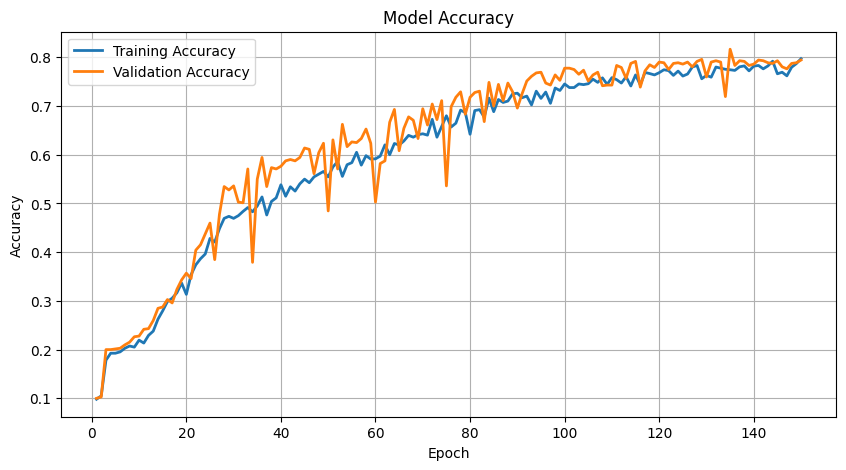

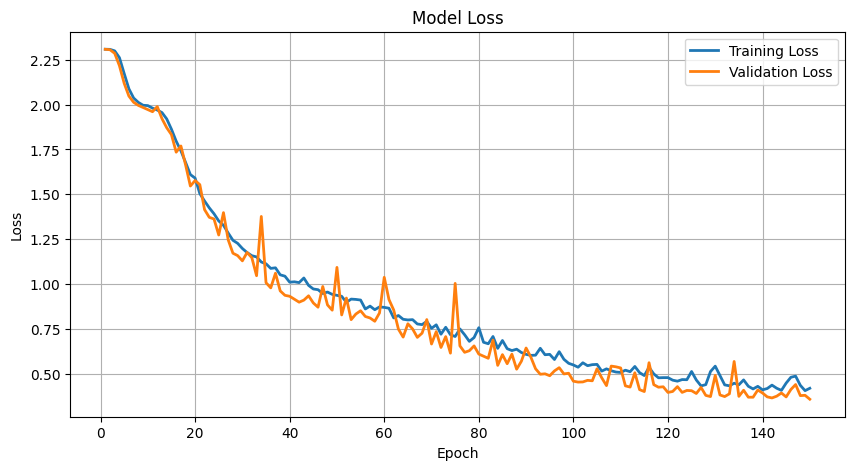

Final Training Accuracy:  0.7972
Final Validation Accuracy: 0.7944
Final Training Loss:       0.4187
Final Validation Loss:     0.3577


In [70]:
acc = history["train_accuracy"]
val_acc = history["dev_accuracy"]
loss = history["train_loss"]
val_loss = history["dev_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, label="Training Loss", linewidth=2)
plt.plot(epochs, val_loss, label="Validation Loss", linewidth=2)
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Accuracy:  {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

## 5.3. Analisis dan Evaluasi Base Model

================ Evaluasi Base Model ================
              precision    recall  f1-score   support

         Apa       1.00      1.00      1.00        72
      Dimana       0.00      0.00      0.00        72
       Hallo       0.00      0.00      0.00        72
        Kamu       0.33      1.00      0.50        72
        Kita       1.00      1.00      1.00        72
      Nunggu       1.00      1.00      1.00        72
        Saya       1.00      0.97      0.99        72
       Siapa       1.00      1.00      1.00        72
       Sudah       0.97      1.00      0.99        72
Terima Kasih       1.00      1.00      1.00        72

    accuracy                           0.80       720
   macro avg       0.73      0.80      0.75       720
weighted avg       0.73      0.80      0.75       720



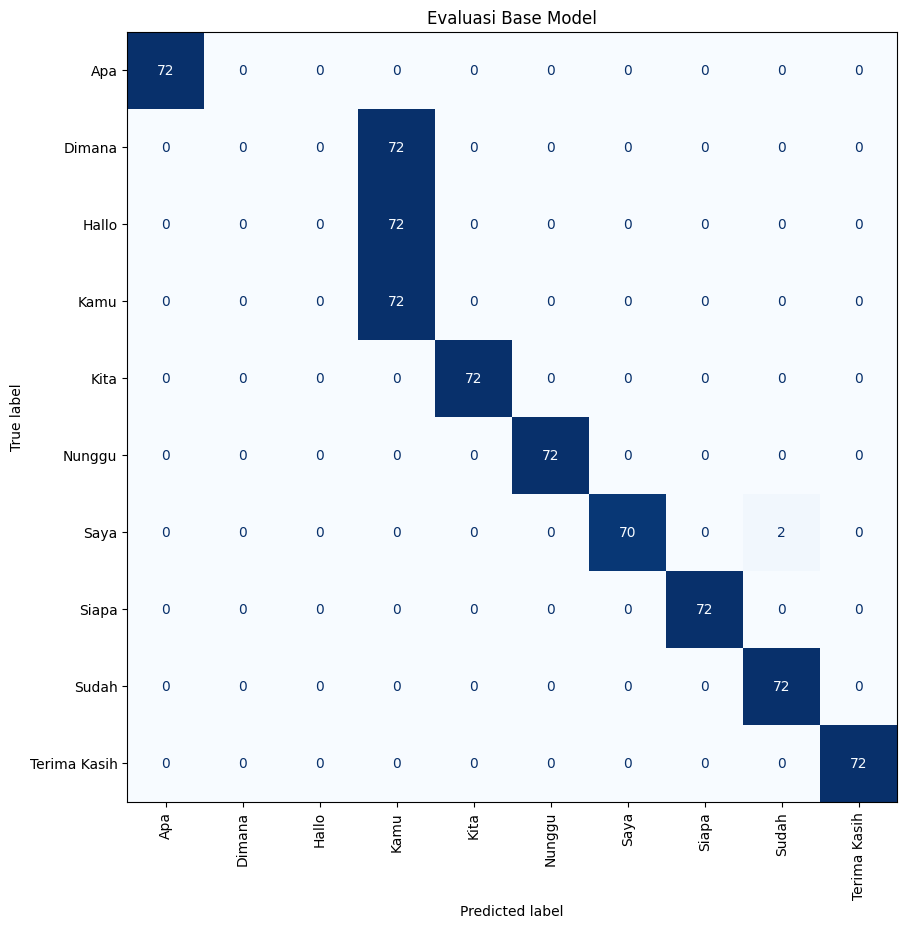

In [71]:
def predict(model, loader):
    model.eval()
    predictions, targets = [], []
    with torch.no_grad():
        for features, batch_targets in loader:
            logits = model(features.to(device))
            predictions.extend(logits.argmax(dim=1).cpu().numpy())
            targets.extend(batch_targets.numpy())
    return np.asarray(targets), np.asarray(predictions)


def evaluate_model(model, loader, title):
    y_true, y_pred = predict(model, loader)
    print(f"================ {title} ================")
    print(classification_report(
        y_true, y_pred, labels=np.arange(len(actions)), target_names=actions, zero_division=0
    ))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(actions)))
    fig, ax = plt.subplots(figsize=(12, 10))
    ConfusionMatrixDisplay(cm, display_labels=actions).plot(
        cmap=plt.cm.Blues, ax=ax, xticks_rotation="vertical", colorbar=False
    )
    ax.set_title(title)
    plt.show()
    return y_true, y_pred


y_true_base, y_pred_base = evaluate_model(base_model, test_loader, "Evaluasi Base Model")

In [72]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = run_epoch(base_model, test_loader, criterion)
print("Mengevaluasi model pada Test Set...")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Mengevaluasi model pada Test Set...
Test Loss     : 0.3629
Test Accuracy : 0.7972 (79.72%)


## 5.4. Simpan Base Model

In [ ]:
MODEL_DIR = Path("base_model")
MODEL_DIR.mkdir(exist_ok=True)
base_checkpoint = MODEL_DIR / "model_cnn_lstm_isyarat.pt"

torch.save(
    {
        "model_state_dict": base_model.state_dict(),
        "model_config": {
            "filters_1": 64,
            "filters_2": 64,
            "lstm_1": 64,
            "lstm_2": 64,
            "lstm_3": 64,
            "dense_1": 64,
            "dense_2": 32,
            "dropout": 0.2
        },
        "actions": actions.tolist(),
        "video_frames": VIDEO_FRAMES,
        "features": FEATURES,
    },
    base_checkpoint,
)
print(f"Base model disimpan di {base_checkpoint}")

Base model disimpan di base_model/model_cnn_lstm_isyarat.pt


# 6. Hyperparameter Tuning

## 6.1. Setup Tuner

In [74]:
def sample_hyperparameters():
    return {
        "filters_1": random.choice([32, 64, 96, 128]),
        "filters_2": random.choice([32, 64, 96, 128]),
        "lstm_1": random.choice([32, 64, 96, 128]),
        "lstm_2": random.choice([32, 64, 96, 128]),
        "lstm_3": random.choice([64, 128, 192, 256]),
        "dense_1": random.choice([32, 64, 96, 128]),
        "dense_2": random.choice([32, 64, 96, 128]),
        "dropout": random.choice([0.1, 0.2, 0.3]),
    }


MAX_TRIALS = 100
TUNING_EPOCHS = 100
trial_results = []

## 6.2. Melakukan Hyperparameter Tuning

In [75]:
for trial_index in range(1, MAX_TRIALS + 1):
    config = sample_hyperparameters()
    print(f"\nTrial {trial_index}/{MAX_TRIALS}: {config}")
    trial_model = CNNLSTM(num_classes=len(actions), **config).to(device)
    trial_history = fit_model(
        trial_model,
        train_loader,
        dev_loader,
        epochs=TUNING_EPOCHS,
        patience=PATIENCE,
        learning_rate=1e-4,
    )
    trial_results.append({
        "config": config,
        "dev_accuracy": max(trial_history["dev_accuracy"]),
    })


Trial 1/100: {'filters_1': 32, 'filters_2': 32, 'lstm_1': 96, 'lstm_2': 64, 'lstm_3': 128, 'dense_1': 64, 'dense_2': 32, 'dropout': 0.3}
Epoch 001/100 | train loss 2.3082, acc 0.1000 | dev loss 2.3076, acc 0.1000
Epoch 002/100 | train loss 2.3074, acc 0.1000 | dev loss 2.3069, acc 0.1000
Epoch 003/100 | train loss 2.3055, acc 0.1000 | dev loss 2.3006, acc 0.1000
Epoch 004/100 | train loss 2.2857, acc 0.1528 | dev loss 2.2509, acc 0.2000
Epoch 005/100 | train loss 2.1929, acc 0.1954 | dev loss 2.1158, acc 0.2000
Epoch 006/100 | train loss 2.0880, acc 0.1972 | dev loss 2.0363, acc 0.2000
Epoch 007/100 | train loss 2.0478, acc 0.1894 | dev loss 2.0125, acc 0.2000
Epoch 008/100 | train loss 2.0222, acc 0.1944 | dev loss 1.9994, acc 0.2000
Epoch 009/100 | train loss 2.0059, acc 0.1926 | dev loss 1.9932, acc 0.2000
Epoch 010/100 | train loss 1.9962, acc 0.2074 | dev loss 1.9884, acc 0.2000
Epoch 011/100 | train loss 1.9971, acc 0.1954 | dev loss 1.9859, acc 0.2000
Epoch 012/100 | train loss

In [76]:
best_trial = max(trial_results, key=lambda result: result["dev_accuracy"])
best_config = best_trial["config"]
print("=== Pencarian Selesai! ===")
print("Kombinasi Hyperparameter Terbaik Ditemukan:")
print(best_config)
print(f"Best Dev Accuracy: {best_trial['dev_accuracy']:.4f}")

=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
{'filters_1': 128, 'filters_2': 96, 'lstm_1': 96, 'lstm_2': 64, 'lstm_3': 128, 'dense_1': 96, 'dense_2': 32, 'dropout': 0.1}
Best Dev Accuracy: 1.0000


In [77]:
print("Me-retrain model terbaik...")
tuned_model = CNNLSTM(num_classes=len(actions), **best_config).to(device)
tuned_history = fit_model(tuned_model, train_loader, dev_loader)

Me-retrain model terbaik...
Epoch 001/150 | train loss 2.3061, acc 0.1000 | dev loss 2.3056, acc 0.1000
Epoch 002/150 | train loss 2.3016, acc 0.1056 | dev loss 2.2857, acc 0.1944
Epoch 003/150 | train loss 2.2125, acc 0.1931 | dev loss 2.1221, acc 0.2000
Epoch 004/150 | train loss 2.0734, acc 0.2042 | dev loss 2.0358, acc 0.2000
Epoch 005/150 | train loss 2.0213, acc 0.2009 | dev loss 2.0079, acc 0.2000
Epoch 006/150 | train loss 2.0046, acc 0.1977 | dev loss 1.9949, acc 0.2000
Epoch 007/150 | train loss 1.9941, acc 0.1995 | dev loss 1.9883, acc 0.2000
Epoch 008/150 | train loss 1.9887, acc 0.1940 | dev loss 1.9849, acc 0.2000
Epoch 009/150 | train loss 1.9860, acc 0.2019 | dev loss 1.9830, acc 0.2000
Epoch 010/150 | train loss 1.9852, acc 0.2000 | dev loss 1.9819, acc 0.2000
Epoch 011/150 | train loss 1.9859, acc 0.1898 | dev loss 1.9811, acc 0.1972
Epoch 012/150 | train loss 1.9821, acc 0.2000 | dev loss 1.9804, acc 0.2000
Epoch 013/150 | train loss 1.9981, acc 0.1958 | dev loss 1.9

## 6.3. Analisis Model Terbaik Setelah Tuning

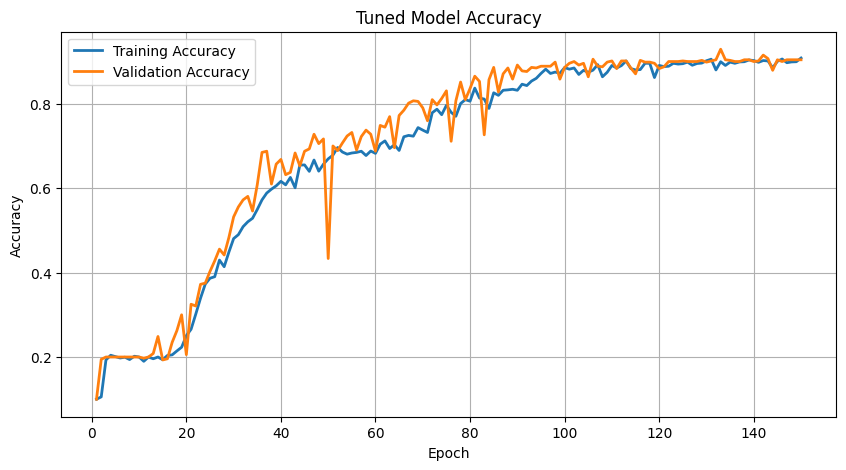

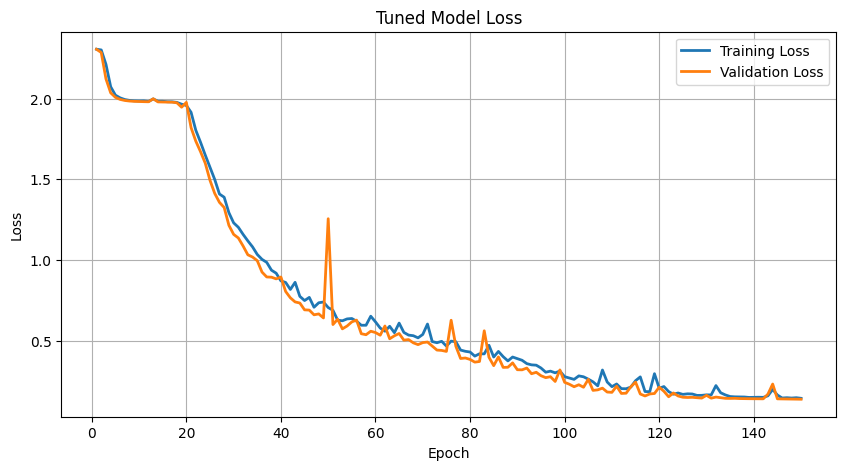

Final Training Accuracy:  0.9083
Final Validation Accuracy: 0.9042
Final Training Loss:       0.1426
Final Validation Loss:     0.1369


In [78]:
acc_tuned = tuned_history["train_accuracy"]
val_acc_tuned = tuned_history["dev_accuracy"]
loss_tuned = tuned_history["train_loss"]
val_loss_tuned = tuned_history["dev_loss"]
epochs_tuned = range(1, len(acc_tuned) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_tuned, acc_tuned, label="Training Accuracy", linewidth=2)
plt.plot(epochs_tuned, val_acc_tuned, label="Validation Accuracy", linewidth=2)
plt.title("Tuned Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_tuned, loss_tuned, label="Training Loss", linewidth=2)
plt.plot(epochs_tuned, val_loss_tuned, label="Validation Loss", linewidth=2)
plt.title("Tuned Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Accuracy:  {acc_tuned[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc_tuned[-1]:.4f}")
print(f"Final Training Loss:       {loss_tuned[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss_tuned[-1]:.4f}")

================ Confusion Matrix Model Setelah Hyperparameter Tuning ================
              precision    recall  f1-score   support

         Apa       1.00      1.00      1.00        72
      Dimana       1.00      1.00      1.00        72
       Hallo       1.00      1.00      1.00        72
        Kamu       1.00      1.00      1.00        72
        Kita       1.00      1.00      1.00        72
      Nunggu       0.51      1.00      0.67        72
        Saya       1.00      0.03      0.05        72
       Siapa       1.00      1.00      1.00        72
       Sudah       1.00      1.00      1.00        72
Terima Kasih       1.00      1.00      1.00        72

    accuracy                           0.90       720
   macro avg       0.95      0.90      0.87       720
weighted avg       0.95      0.90      0.87       720



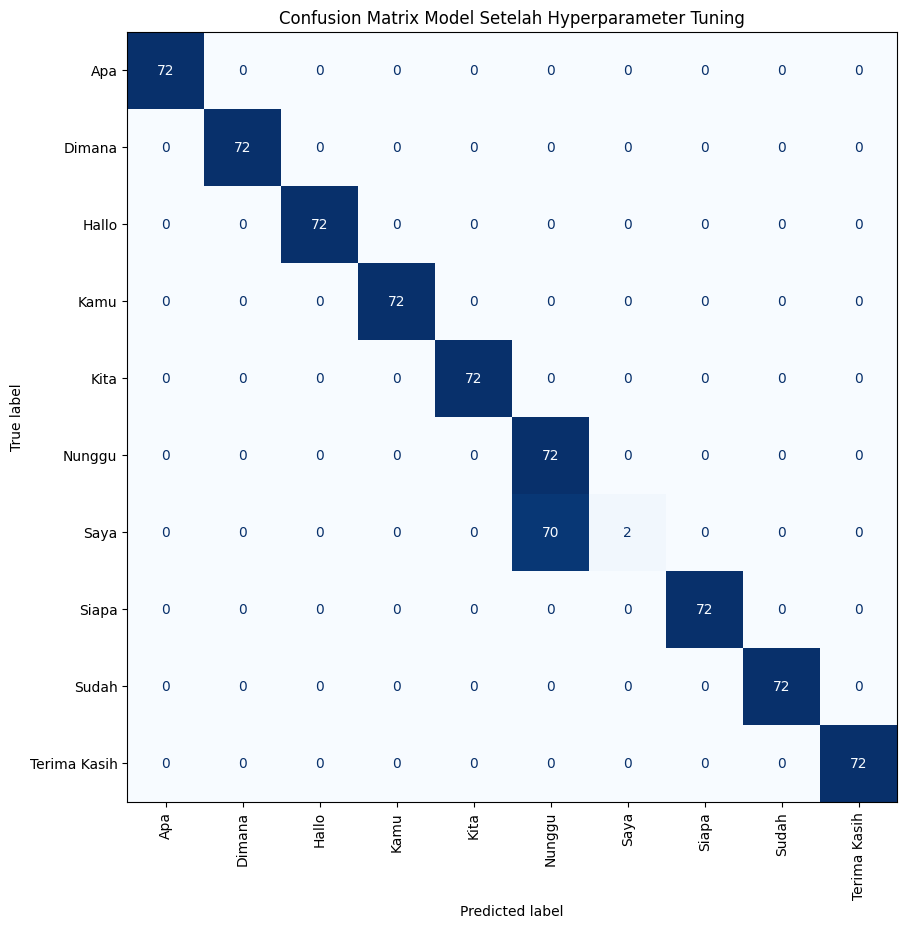

Mengevaluasi model tuned pada Test Set...
Test Loss     : 0.1383
Test Accuracy : 0.9028 (90.28%)


In [79]:
y_true_tuned, y_pred_tuned = evaluate_model(
    tuned_model,
    test_loader,
    "Confusion Matrix Model Setelah Hyperparameter Tuning",
)
criterion = nn.CrossEntropyLoss()
tuned_test_loss, tuned_test_accuracy = run_epoch(tuned_model, test_loader, criterion)
print("Mengevaluasi model tuned pada Test Set...")
print(f"Test Loss     : {tuned_test_loss:.4f}")
print(f"Test Accuracy : {tuned_test_accuracy:.4f} ({tuned_test_accuracy * 100:.2f}%)")

## 6.4. Simpan Model Terbaik

In [80]:
BEST_MODEL_DIR = Path("best_model")
BEST_MODEL_DIR.mkdir(exist_ok=True)
best_checkpoint = BEST_MODEL_DIR / "model_cnn_lstm_isyarat.pt"
torch.save(
    {
        "model_state_dict": tuned_model.state_dict(),
        "model_config": best_config,
        "actions": actions.tolist(),
        "video_frames": VIDEO_FRAMES,
        "features": FEATURES,
    },
    best_checkpoint,
)
print(f"Best model disimpan di {best_checkpoint}")

Best model disimpan di best_model/model_cnn_lstm_isyarat.pt
